In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

In [7]:
df=pd.read_csv('DATOS.csv')
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,booking_status_Canceled
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,1.0,0.0,0.0,0.0
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,0.0,0.0,1.0,0.0
2,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0,1.0,0.0,0.0,1.0
3,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0,1.0,0.0,0.0,1.0
4,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0,0.0,0.0,1.0,1.0


Separación de la etiqueta del estado de la reservación (si está cancelada(etiqueta=1) o no(etiqueta=0))

In [8]:
X=df.drop(columns='booking_status_Canceled')
y=df['booking_status_Canceled']

Separación de datos en datos de entrenamiento y de prueba

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

Hiperparámetros:

In [13]:
param_grid = {
    "n_estimators": [80],
    "max_depth": [None],#default
    "min_samples_split": [2], #default
    "min_samples_leaf": [1], #default
    "max_features": ["sqrt"],#default
    "criterion": ["gini"]#default
}

Modelo:

In [14]:
rf = RandomForestClassifier()
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

Fase de Entrenamiento

In [15]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini'], 'max_depth': [None], 'max_features': ['sqrt'], 'min_samples_leaf': [1], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

Elección del mejor modelo implementado

In [16]:
best_model = grid_search.best_estimator_

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

print("\nMejor accuracy en validación cruzada:")
print(grid_search.best_score_)

Mejores hiperparámetros encontrados:
{'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 80}

Mejor accuracy en validación cruzada:
0.8408561541614648


Predicción del modelo

In [18]:
y_pred=best_model.predict(X_test)

Métricas del modelo

In [23]:
print(classification_report(y_test, y_pred))
# 0=no canceló reservación
#1= sí canceló reservación

              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90      3709
         1.0       0.77      0.65      0.71      1454

    accuracy                           0.85      5163
   macro avg       0.82      0.79      0.80      5163
weighted avg       0.84      0.85      0.84      5163



Matriz de confusión

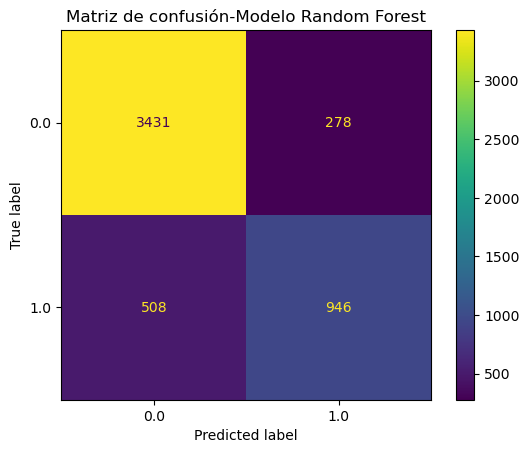

In [25]:
cm = confusion_matrix(y_test, y_pred)
matriz = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=y.unique()
)
matriz.plot()
plt.title("Matriz de confusión-Modelo Random Forest")
plt.show()

Métricas para el conjunto de entrenamiento

In [27]:
#El siguiente proceso sirve para determinar si hay sobreajuste en el modelo
y_pred_train = best_model.predict(X_train)
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14833
         1.0       0.99      0.99      0.99      5815

    accuracy                           1.00     20648
   macro avg       0.99      0.99      0.99     20648
weighted avg       1.00      1.00      1.00     20648



Matriz de connfusión para el conjunto de entrenamiento

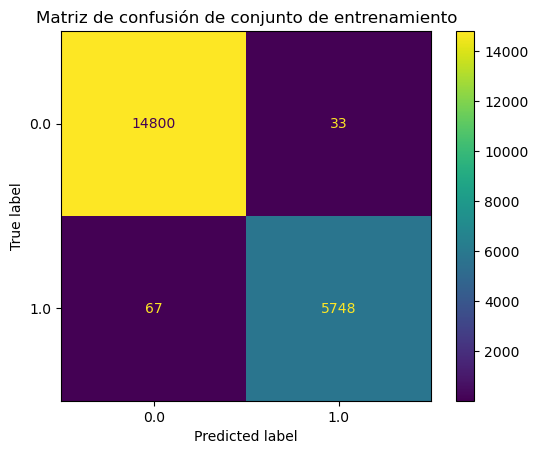

In [28]:
cm = confusion_matrix(y_train, y_pred_train)
mat_train = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=y.unique()
)
mat_train.plot()
plt.title('Matriz de confusión de conjunto de entrenamiento')
plt.show()